# Data Wrangling
<b><b><b>
- Involves manipulating data to achieve a desired result.<br><br>
- Manipulation can include but not limited to: <br><br>
    - Combining sets of data (concatentate and merging) <br><br>
    - Summarizing data <br><br>
    - Dealing with unwanted entries (e.g. imputing missing values, Removal of entries) <br><br>
    

## 1 Concatenation
- Consider the following 2 dataframes found in section 1.9.2 in the online course notes

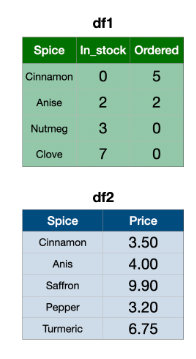

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
import numpy as np

### 1.1 Create the two dataframes

In [5]:
df1 = pd.DataFrame(
{
    "Spice": ["Cinnamon", "Anise", "Nutmeg", "Clove"],
    "In_stock": [0, 2, 3, 7],
    "Ordered": [5, 2, 0, 0],
}
)
df1

,Spice,In_stock,Ordered
0,Cinnamon,0,5
1,Anise,2,2
2,Nutmeg,3,0
3,Clove,7,0


In [4]:
df2 = pd.DataFrame(
{
    "Spice": ["Cinnamon", "Anise", "Saffron", "Pepper", "Turmeric"],
    "Price": [3.5, 4.0, 9.9, 3.2, 6.75],
}
)
df2

,Spice,Price
0,Cinnamon,3.50
1,Anise,4.00
2,Saffron,9.90
3,Pepper,3.20
4,Turmeric,6.75


### 1.2 Concatenate 
- by row:
    - Involves stacking up different dataframes

In [6]:
pd.concat([df1, df2], axis=0)

,Spice,In_stock,Ordered,Price
0,Cinnamon,0.0,5.0,NaN
1,Anise,2.0,2.0,NaN
2,Nutmeg,3.0,0.0,NaN
3,Clove,7.0,0.0,NaN
0,Cinnamon,NaN,NaN,3.50
1,Anise,NaN,NaN,4.00
2,Saffron,NaN,NaN,9.90
3,Pepper,NaN,NaN,3.20
4,Turmeric,NaN,NaN,6.75


- by column:
    - Involves appending dataframes to the right

In [7]:
pd.concat([df1, df2], axis=1)

,Spice,In_stock,Ordered,Spice,Price
0,Cinnamon,0.0,5.0,Cinnamon,3.50
1,Anise,2.0,2.0,Anise,4.00
2,Nutmeg,3.0,0.0,Saffron,9.90
3,Clove,7.0,0.0,Pepper,3.20
4,NaN,NaN,NaN,Turmeric,6.75


In [13]:
# How about when we set the index to "Spice"
df1_new = df1.set_index("Spice")
df2_new = df2.set_index("Spice")
#pd.concat([df1_new, df2_new])
#pd.concat([df1_new, df2_new], axis=1)

In [14]:
pd.DataFrame({"temp": [12.2, 13.4, 2.5],
"humidity": [60, 70, 40]})

,temp,humidity
0,12.2,60
1,13.4,70
2,2.5,40


### 1.3 Merging
- Combining dataframes based on values in shared columns
    - The hyperparameter `on` in `pd.merge` determines the shared columns <br><br>
- Types of merging:
    - inner/outer
        - inner: returns only matched entries based on the shared column(s) (no missing values)
        - outer: may produce missing values on either side
    - left/right: Allows us to decide which dataframe results in missing values (no need to change the order of how the dataframes are supplied to the merge function)<br><br>
    

### 1.3.1 Inner merge

In [15]:
pd.merge(df1, df2, on="Spice", how="inner")

,Spice,In_stock,Ordered,Price
0,Cinnamon,0,5,3.5
1,Anise,2,2,4.0


### 1.3.2 Outer merge
- depending on which df is supplied first, the other dfs may have missing values

In [16]:
pd.merge(df1, df2, on="Spice", how="outer")

,Spice,In_stock,Ordered,Price
0,Cinnamon,0.0,5.0,3.50
1,Anise,2.0,2.0,4.00
2,Nutmeg,3.0,0.0,NaN
3,Clove,7.0,0.0,NaN
4,Saffron,NaN,NaN,9.90
5,Pepper,NaN,NaN,3.20
6,Turmeric,NaN,NaN,6.75


In [17]:
pd.merge(df2, df1, on="Spice", how="outer")

,Spice,Price,In_stock,Ordered
0,Cinnamon,3.50,0.0,5.0
1,Anise,4.00,2.0,2.0
2,Saffron,9.90,NaN,NaN
3,Pepper,3.20,NaN,NaN
4,Turmeric,6.75,NaN,NaN
5,Nutmeg,NaN,3.0,0.0
6,Clove,NaN,7.0,0.0


In [18]:
pd.merge(df2, df1, on="Spice", how="outer").dropna()

,Spice,Price,In_stock,Ordered
0,Cinnamon,3.5,0.0,5.0
1,Anise,4.0,2.0,2.0


### 1.3.3 left and right merge
- With left and right methods, one can choose which dataframe results in missing values

In [19]:
pd.merge(left=df1, right=df2, on="Spice", how="left")

,Spice,In_stock,Ordered,Price
0,Cinnamon,0,5,3.5
1,Anise,2,2,4.0
2,Nutmeg,3,0,NaN
3,Clove,7,0,NaN


In [23]:
pd.merge(df1, df2, on="Spice", how="right")

,Spice,In_stock,Ordered,Price
0,Cinnamon,0.0,5.0,3.50
1,Anise,2.0,2.0,4.00
2,Saffron,NaN,NaN,9.90
3,Pepper,NaN,NaN,3.20
4,Turmeric,NaN,NaN,6.75


## 2 Dealing with missing values
- Where are the missing values?
- What could be the causes?
- What to do with them?
    - Remove?
    - Fill?

- We use the outer merge for `df2` and `df1`

In [24]:
df = pd.merge(df2, df1, how="outer", on="Spice")
df

,Spice,Price,In_stock,Ordered
0,Cinnamon,3.50,0.0,5.0
1,Anise,4.00,2.0,2.0
2,Saffron,9.90,NaN,NaN
3,Pepper,3.20,NaN,NaN
4,Turmeric,6.75,NaN,NaN
5,Nutmeg,NaN,3.0,0.0
6,Clove,NaN,7.0,0.0


### 2.1 Count the number of missing values

In [28]:
df.isna().sum().sum()

8

In [34]:
df.isnull().sum().sum()

8

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Spice     7 non-null      object 
 1   Price     5 non-null      float64
 2   In_stock  4 non-null      float64
 3   Ordered   4 non-null      float64
dtypes: float64(3), object(1)
memory usage: 352.0+ bytes


### 2.2 How to drop all rows with missing values

In [36]:
df.dropna()

,Spice,Price,In_stock,Ordered
0,Cinnamon,3.5,0.0,5.0
1,Anise,4.0,2.0,2.0


### 2.3 How to fill missing values with a certain value
- For example -9999

In [38]:
df.fillna(-9999)

,Spice,Price,In_stock,Ordered
0,Cinnamon,3.50,0.0,5.0
1,Anise,4.00,2.0,2.0
2,Saffron,9.90,-9999.0,-9999.0
3,Pepper,3.20,-9999.0,-9999.0
4,Turmeric,6.75,-9999.0,-9999.0
5,Nutmeg,-9999.00,3.0,0.0
6,Clove,-9999.00,7.0,0.0


### 2.4 Exercise: Fill the missing values with the mean of the column

### 2.5 Visualizing missing values

- Set index on `Spice` column and assign to a new `df`

In [39]:
df_new = df.set_index("Spice")
df_new

,Price,In_stock,Ordered
Spice,,,
Cinnamon,3.50,0.0,5.0
Anise,4.00,2.0,2.0
Saffron,9.90,NaN,NaN
Pepper,3.20,NaN,NaN
Turmeric,6.75,NaN,NaN
Nutmeg,NaN,3.0,0.0
Clove,NaN,7.0,0.0


- Visualize

<Axes: ylabel='Spice'>

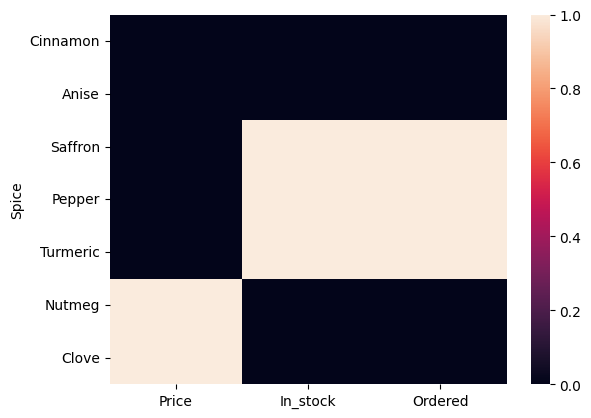

In [40]:
sns.heatmap(df_new.isna())

### 2.6 Remove all columns containing at least 3 missing values

In [66]:
df.dropna(subset=3, axis=1)

,Spice,Price
0,Cinnamon,3.50
1,Anise,4.00
2,Saffron,9.90
3,Pepper,3.20
4,Turmeric,6.75
5,Nutmeg,NaN
6,Clove,NaN


### 2.6.1 retain all columns with at least 5 non-missing values

In [67]:
df.dropna(thresh=5, axis=1)

,Spice,Price
0,Cinnamon,3.50
1,Anise,4.00
2,Saffron,9.90
3,Pepper,3.20
4,Turmeric,6.75
5,Nutmeg,NaN
6,Clove,NaN


### 3 Exercise on data wrangling using penguins data

- Use the data folder in the directory containing this notebook<br><br>
- The folder contains among others, the following files:<br><br>
    - `penguins_adelie.csv`
    - `penguins_gentoo.csv`
    - `penguins_chinstrap.csv`
    - `sex_data_penguins.csv`<br><br>
- Read the data files in pandas<br><br>
- Concatenate the first 3 dataframes above (without sex data) <br><br>
- inner merge the sex data to the concantenated dataframe on `sample ID`, `Species` and `Sample Number`<br><br>
- Count the number of missing values<br><br>
- Visualize the missing values using a heat map<br><br>
- Drop all the missing values<br><br>
- Drop columns with missing values > 10<br><br>
- Fill the mising values with the mean of each column<br><br>
- Remove strange values from the `SEX` column (values like `nan`, `.` etc). Hint: use `.unique()` method<br><br>
- Save the file as a csv file<br><br>
